## **Types of Chunking (Splitters)**

### How to fix size of a web image using markdown ( see code below )

<div style="width: 600px">

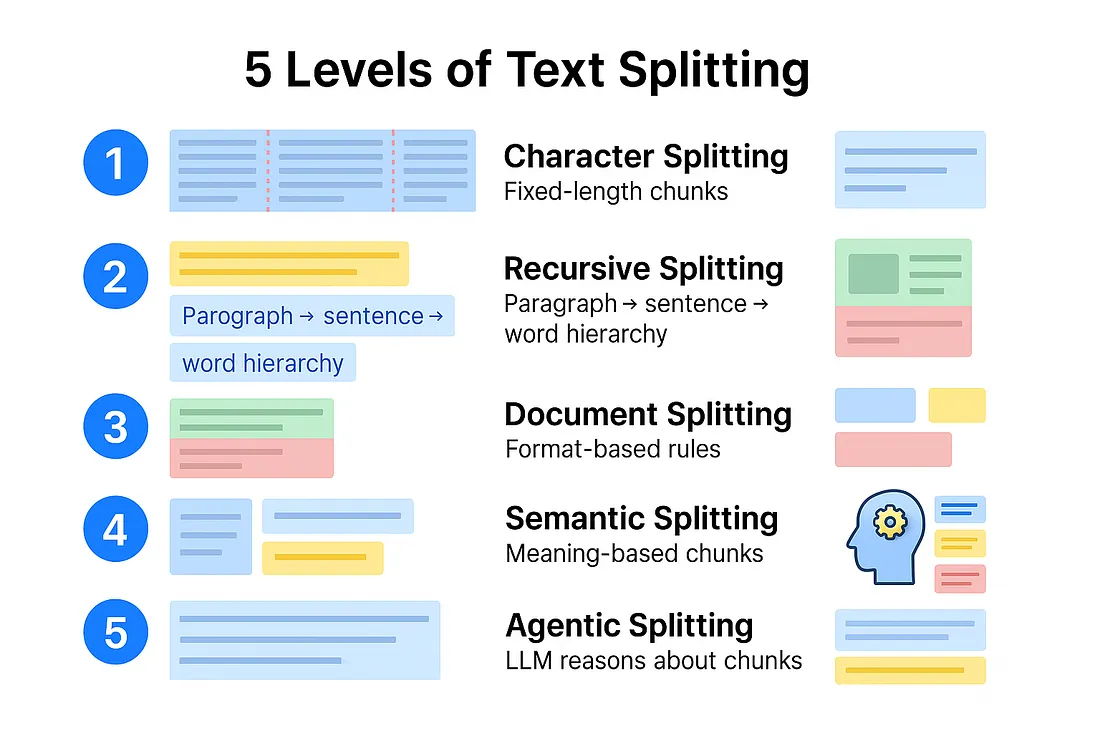
<!-- These new line spaces should be kept as it is so that vscode understands it -->
</div>

https://medium.com/@dewasheesh.rana/the-definitive-guide-to-agentic-rag-text-splitting-chunking-a75766ee307c

## **A. Length Based Splitting**

#### Advantages:
- Simple and straightforward to implement 
- Predictable chunk sizes fit model context windows
- Fast processing speed
- Consistent memory usage
- Easy to parallelize

#### Disadvantages:
- May split sentences or paragraphs mid-thought, breaking semantic meaning
- No consideration of document structure or meaning
- Can separate related information across chunks
- Overlap creates data redundancy (duplicate)
- Not optimal for documents with varied structure

#### Types:
- Text
- Token
- Document

### **Text Splitters** 

In [1]:
from langchain_text_splitters import CharacterTextSplitter
from pprint import pp

In [2]:
text = """Artificial intelligence is transforming technology and shaping the future.
Machine learning algorithms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of data efficiently.

Natural language processing pas made significant strides in recent years.
Computer vision systems can now identify objects with remarkable accuracy
Reinforcement learning is enabling robots to learn complex tasks autonomously.

The impact of AI extends across multiple industries including healthcare, finance, and transport
Ethical considerations around AI development are becoming increasingly important.
Researchers are working on making AI systems more transparent and explainable."""

In [3]:
# Create the Splitter Object
splitter = CharacterTextSplitter(
    chunk_size= 100,            # Threshold 
    chunk_overlap= 0,
    length_function= len,       # OR can be  a custom function too
    separator= ""
)

In [4]:
# Split the text
chunks= splitter.split_text(text)

pp(chunks)
print("Number of chunks: ", len(chunks))

['Artificial intelligence is transforming technology and shaping the future.\n'
 'Machine learning algorith',
 'ms are becoming more sophisticated every day.\n'
 'Deep learning models can now process vast amounts of d',
 'ata efficiently.\n'
 '\n'
 'Natural language processing pas made significant strides in recent years.\n'
 'Computer',
 'vision systems can now identify objects with remarkable accuracy\n'
 'Reinforcement learning is enabling',
 'robots to learn complex tasks autonomously.\n'
 '\n'
 'The impact of AI extends across multiple industries in',
 'cluding healthcare, finance, and transport\n'
 'Ethical considerations around AI development are becoming',
 'increasingly important.\n'
 'Researchers are working on making AI systems more transparent and explainab',
 'le.']
Number of chunks:  8


#### **Adding colors to text**

In [5]:
from termcolor import COLORS, colored
from random import choice

print(COLORS)

{'black': 30, 'grey': 30, 'red': 31, 'green': 32, 'yellow': 33, 'blue': 34, 'magenta': 35, 'cyan': 36, 'light_grey': 37, 'dark_grey': 90, 'light_red': 91, 'light_green': 92, 'light_yellow': 93, 'light_blue': 94, 'light_magenta': 95, 'light_cyan': 96, 'white': 97}


In [ ]:
colors_list= list(COLORS.keys())[2:8] 
print(colors_list)

['red', 'green', 'yellow', 'blue', 'magenta', 'cyan']


In [ ]:
def display_chunks(chunks):
    print(f"Total Number of Chunks: {len(chunks)}")
    for num, chunk in enumerate(chunks,1):              
    # chunks is a list, enumerate(number,item) helps to start iterator index from '1' here (else default 0) corresponding to each element of that list (i.e. named 'chunk' here)  
        print(f"Number of characters in chunk {num}: {len(chunk)} chars")
        colors_list= list(COLORS.keys())[2:8]
        print( colored( text= chunk, color=  choice(colors_list) ), end= "\n\n")

In [8]:
display_chunks(chunks)

Total Number of Chunks: 8
Number of characters in chunk 1: 100 chars
Artificial intelligence is transforming technology and shaping the future.
Machine learning algorith

Number of characters in chunk 2: 100 chars
ms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of d

Number of characters in chunk 3: 100 chars
ata efficiently.

Natural language processing pas made significant strides in recent years.
Computer

Number of characters in chunk 4: 99 chars
vision systems can now identify objects with remarkable accuracy
Reinforcement learning is enabling

Number of characters in chunk 5: 99 chars
robots to learn complex tasks autonomously.

The impact of AI extends across multiple industries in

Number of characters in chunk 6: 100 chars
cluding healthcare, finance, and transport
Ethical considerations around AI development are becoming

Number of characters in chunk 7: 99 chars
increasingly important.
Researchers are working on making AI syste

#### Simple Rule: Load the Object(CharacterTextSplitter()), Apply its method(.split_text())

In [9]:
## Creating the CHUNKS
def create_chunk( text: str, chunk_size: int, separator: str, chunk_overlap: int=0) -> list[str]:
    splitter= CharacterTextSplitter(chunk_size= chunk_size, separator= separator, chunk_overlap= chunk_overlap)
    chunks= splitter.split_text(text)
    return chunks                              

#### **Trying Different Separators: Both Max chunk_size and separator property is followed while splitting**

In [36]:
display_chunks(create_chunk(text, 100, ""))              # Dual Function Calling

Total Number of Chunks: 8
Number of characters in chunk 1: 100 chars
Artificial intelligence is transforming technology and shaping the future.
Machine learning algorith

Number of characters in chunk 2: 100 chars
ms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of d

Number of characters in chunk 3: 100 chars
ata efficiently.

Natural language processing pas made significant strides in recent years.
Computer

Number of characters in chunk 4: 99 chars
vision systems can now identify objects with remarkable accuracy
Reinforcement learning is enabling

Number of characters in chunk 5: 99 chars
robots to learn complex tasks autonomously.

The impact of AI extends across multiple industries in

Number of characters in chunk 6: 100 chars
cluding healthcare, finance, and transport
Ethical considerations around AI development are becoming

Number of characters in chunk 7: 99 chars
increasingly important.
Researchers are working on making AI syste

In [37]:
display_chunks(create_chunk(text, 100, " "))              # Dual Function Calling

Total Number of Chunks: 8
Number of characters in chunk 1: 91 chars
Artificial intelligence is transforming technology and shaping the future.
Machine learning

Number of characters in chunk 2: 95 chars
algorithms are becoming more sophisticated every day.
Deep learning models can now process vast

Number of characters in chunk 3: 96 chars
amounts of data efficiently.

Natural language processing pas made significant strides in recent

Number of characters in chunk 4: 94 chars
years.
Computer vision systems can now identify objects with remarkable accuracy
Reinforcement

Number of characters in chunk 5: 97 chars
learning is enabling robots to learn complex tasks autonomously.

The impact of AI extends across

Number of characters in chunk 6: 97 chars
multiple industries including healthcare, finance, and transport
Ethical considerations around AI

Number of characters in chunk 7: 98 chars
development are becoming increasingly important.
Researchers are working on making AI systems more

In [12]:
display_chunks(create_chunk(text, 100, "\n"))              # Dual Function Calling

Total Number of Chunks: 9
Number of characters in chunk 1: 74 chars
Artificial intelligence is transforming technology and shaping the future.

Number of characters in chunk 2: 70 chars
Machine learning algorithms are becoming more sophisticated every day.

Number of characters in chunk 3: 70 chars
Deep learning models can now process vast amounts of data efficiently.

Number of characters in chunk 4: 73 chars
Natural language processing pas made significant strides in recent years.

Number of characters in chunk 5: 73 chars
Computer vision systems can now identify objects with remarkable accuracy

Number of characters in chunk 6: 78 chars
Reinforcement learning is enabling robots to learn complex tasks autonomously.

Number of characters in chunk 7: 96 chars
The impact of AI extends across multiple industries including healthcare, finance, and transport

Number of characters in chunk 8: 81 chars
Ethical considerations around AI development are becoming increasingly important.

Number 

In [13]:
display_chunks(create_chunk(text, 100, "\n\n"))              # Dual Function Calling

Created a chunk of size 216, which is longer than the specified 100
Created a chunk of size 226, which is longer than the specified 100


Total Number of Chunks: 3
Number of characters in chunk 1: 216 chars
Artificial intelligence is transforming technology and shaping the future.
Machine learning algorithms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of data efficiently.

Number of characters in chunk 2: 226 chars
Natural language processing pas made significant strides in recent years.
Computer vision systems can now identify objects with remarkable accuracy
Reinforcement learning is enabling robots to learn complex tasks autonomously.

Number of characters in chunk 3: 257 chars
The impact of AI extends across multiple industries including healthcare, finance, and transport
Ethical considerations around AI development are becoming increasingly important.
Researchers are working on making AI systems more transparent and explainable.



#### Chunk overlap is used to maintain the continuity of the context

In [ ]:
def display_chunks_with_overlaps(chunks, chunk_overlap):
    if not chunk_overlap:
        raise(ValueError("Chunk Overlap cannot be 0"))

    # create vars
    overlap_text = ""
    overlap_color = "white"
    colors_list = list(COLORS.keys())[2:8]

    print(f"Total Number of Chunks: {len(chunks)}")
    for num, chunk in enumerate(chunks, 1):
        print(f"Chunk {num}: Length {len(chunk)} chars")
        if num == 1:                                                   ## For Chunk 1 , overlap only at end, else overlap at start as well as end
            # print the chunk without overlap
            non_overlap_text = chunk[0 : -chunk_overlap]
            overlap_text = chunk[-chunk_overlap:]                               # Storing last chunk_sized characters in the variable
            print(colored(non_overlap_text, choice(colors_list)), 
                  colored(overlap_text, overlap_color), sep="", end="\n\n")     # White at the end
        else:
            # print the overlap text at start of chunk
            print(colored(overlap_text, overlap_color), end="")                 # The start overlap_text characters are same as the previous one; 
                                                                                # White at the beginning
            # print non overlap text
            non_overlap_text = chunk[chunk_overlap : -chunk_overlap]
            print(colored(non_overlap_text, choice(colors_list)), end="")
            # print overlap text at end of chunk
            overlap_text = chunk[-chunk_overlap: ]
            print(colored(overlap_text, overlap_color), end="\n\n")              # White at the end

In [15]:
display_chunks_with_overlaps(create_chunk(text, 100, ""), 6 )

Total Number of Chunks: 8
Chunk 1: Length 100 chars
Artificial intelligence is transforming technology and shaping the future.
Machine learning algorith

Chunk 2: Length 100 chars
gorith becoming more sophisticated every day.
Deep learning models can now process vast amounts of d

Chunk 3: Length 100 chars
s of dficiently.

Natural language processing pas made significant strides in recent years.
Computer

Chunk 4: Length 99 chars
mputer systems can now identify objects with remarkable accuracy
Reinforcement learning is enabling

Chunk 5: Length 99 chars
abling to learn complex tasks autonomously.

The impact of AI extends across multiple industries in

Chunk 6: Length 100 chars
ies ing healthcare, finance, and transport
Ethical considerations around AI development are becoming

Chunk 7: Length 99 chars
comingsingly important.
Researchers are working on making AI systems more transparent and explainab

Chunk 8: Length 3 chars
lainable.



### **Token Based Splitting**

In [ ]:
token_splitter = CharacterTextSplitter.from_tiktoken_encoder( 
    encoding_name= "cl100k_base", chunk_size= 50, chunk_overlap= 5
)

# cl100k_base is an official encoding/tokenizer used by OpenAI to translate human-readable text into "tokens" (chunks of characters, words, or code) that their AI models can understand

In [46]:
chunks= token_splitter.split_text(text)
print(f"Number of chunks: {len(chunks)}")
chunks

Number of chunks: 3


['Artificial intelligence is transforming technology and shaping the future.\nMachine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of data efficiently.',
 'Natural language processing pas made significant strides in recent years.\nComputer vision systems can now identify objects with remarkable accuracy\nReinforcement learning is enabling robots to learn complex tasks autonomously.',
 'The impact of AI extends across multiple industries including healthcare, finance, and transport\nEthical considerations around AI development are becoming increasingly important.\nResearchers are working on making AI systems more transparent and explainable.']

### **Document Splitting**

In [18]:
from langchain_core.documents import Document

In [ ]:
## Just simply load the text into a Document object
docs= [ Document(
    page_content= text,
    metadata= {"source": "Text on AI"}
)]
docs

[Document(metadata={'source': 'Text on AI'}, page_content='Artificial intelligence is transforming technology and shaping the future.\nMachine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of data efficiently.\n\nNatural language processing pas made significant strides in recent years.\nComputer vision systems can now identify objects with remarkable accuracy\nReinforcement learning is enabling robots to learn complex tasks autonomously.\n\nThe impact of AI extends across multiple industries including healthcare, finance, and transport\nEthical considerations around AI development are becoming increasingly important.\nResearchers are working on making AI systems more transparent and explainable.')]

In [47]:
doc_splitter= CharacterTextSplitter(
    chunk_size= 100,
    chunk_overlap=20,
    separator= ""
)

In [ ]:
doc_chunks= splitter.split_documents(docs)
print(f"Number of chunks: {len(chunks)}")
doc_chunks

Number of chunks: 3


[Document(metadata={'source': 'Text on AI'}, page_content='Artificial intelligence is transforming technology and shaping the future.\nMachine learning algorith'),
 Document(metadata={'source': 'Text on AI'}, page_content='ms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of d'),
 Document(metadata={'source': 'Text on AI'}, page_content='ata efficiently.\n\nNatural language processing pas made significant strides in recent years.\nComputer'),
 Document(metadata={'source': 'Text on AI'}, page_content='vision systems can now identify objects with remarkable accuracy\nReinforcement learning is enabling'),
 Document(metadata={'source': 'Text on AI'}, page_content='robots to learn complex tasks autonomously.\n\nThe impact of AI extends across multiple industries in'),
 Document(metadata={'source': 'Text on AI'}, page_content='cluding healthcare, finance, and transport\nEthical considerations around AI development are becoming'),
 Document(metad

In [53]:
doc_chunk_content= [chunk.page_content for chunk in doc_chunks]
doc_chunk_content

['Artificial intelligence is transforming technology and shaping the future.\nMachine learning algorith',
 'ms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of d',
 'ata efficiently.\n\nNatural language processing pas made significant strides in recent years.\nComputer',
 'vision systems can now identify objects with remarkable accuracy\nReinforcement learning is enabling',
 'robots to learn complex tasks autonomously.\n\nThe impact of AI extends across multiple industries in',
 'cluding healthcare, finance, and transport\nEthical considerations around AI development are becoming',
 'increasingly important.\nResearchers are working on making AI systems more transparent and explainab',
 'le.']

In [55]:
doc_metadata= [chunk.metadata["source"] for chunk in doc_chunks]
doc_metadata

['Text on AI',
 'Text on AI',
 'Text on AI',
 'Text on AI',
 'Text on AI',
 'Text on AI',
 'Text on AI',
 'Text on AI']